In [40]:
!pip install pandas numpy matplotlib torch scikit-learn


In [41]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KernelDensity


In [42]:
r = 102303161
ar = 0.5 * (r % 7)
br = 0.3 * ((r % 5) + 1)

print("a_r =", ar)
print("b_r =", br)


a_r = 1.0
b_r = 0.6


In [43]:
data = pd.read_csv("data.csv")

x = data["no2"].dropna().values
z = x + ar * np.sin(br * x)

z = z.reshape(-1,1)

scale = StandardScaler()
z = scale.fit_transform(z)

zt = torch.tensor(z, dtype=torch.float32)


/tmp/ipython-input-2063109596.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("data.csv")


In [44]:
class generator(nn.Module):
    def __init__(self):
        super(generator,self).__init__()
        self.model = nn.Sequential(
            nn.Linear(1,40),
            nn.ReLU(),
            nn.Linear(40,40),
            nn.ReLU(),
            nn.Linear(40,1)
        )
    def forward(self,x):
        return self.model(x)


In [45]:
class discriminator(nn.Module):
    def __init__(self):
        super(discriminator,self).__init__()
        self.model = nn.Sequential(
            nn.Linear(1,40),
            nn.ReLU(),
            nn.Linear(40,40),
            nn.ReLU(),
            nn.Linear(40,1),
            nn.Sigmoid()
        )
    def forward(self,x):
        return self.model(x)


In [46]:
g = generator()
d = discriminator()

loss = nn.BCELoss()

optg = optim.Adam(g.parameters(), lr=0.001)
optd = optim.Adam(d.parameters(), lr=0.001)


In [47]:
epochs = 3000
batch = 64

for e in range(epochs):

    ids = np.random.randint(0, len(zt), batch)
    real = zt[ids]

    noise = torch.randn(batch,1)
    fake = g(noise)

    outreal = d(real)
    outfake = d(fake.detach())

    lossreal = loss(outreal, torch.ones(batch,1))
    lossfake = loss(outfake, torch.zeros(batch,1))
    lossd = lossreal + lossfake

    optd.zero_grad()
    lossd.backward()
    optd.step()

    outfake = d(fake)
    lossg = loss(outfake, torch.ones(batch,1))

    optg.zero_grad()
    lossg.backward()
    optg.step()


In [48]:
noise = torch.randn(10000,1)
samples = g(noise).detach().numpy()

samples = scale.inverse_transform(samples)


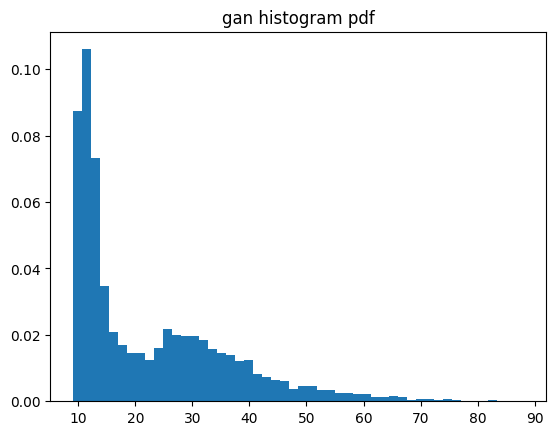

In [49]:
plt.figure()
plt.hist(samples, bins=50, density=True)
plt.title("gan histogram pdf")
plt.show()


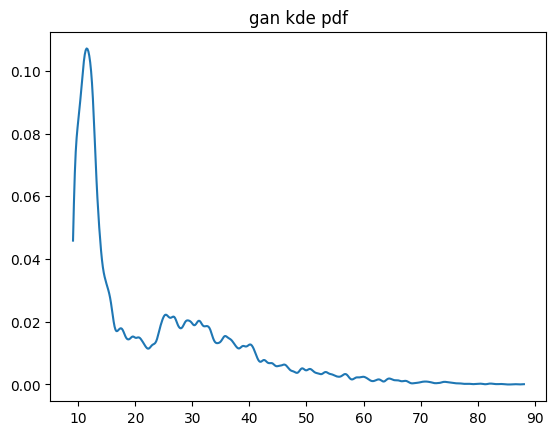

In [50]:
kde = KernelDensity(kernel="gaussian", bandwidth=0.4)
kde.fit(samples)

grid = np.linspace(samples.min(), samples.max(), 500).reshape(-1,1)
logval = kde.score_samples(grid)

plt.figure()
plt.plot(grid, np.exp(logval))
plt.title("gan kde pdf")
plt.show()
